# Module 5 — Day 2 Breakout Exercise
## PHY 657, Spring 2026

---

### Background

You just saw how a neural network is trained: forward pass, compute loss, backward pass (backpropagation), update weights. The code below implements the full training loop from lecture.

Your job: **run it, then break it.** Each failure teaches you something about how neural networks work.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13, 'figure.figsize': (8, 5)})

In [5]:
# --- All the machinery from lecture (just run this cell) ---

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = sigmoid(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def backward(X, y, y_hat, h, W2):
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * h * (1 - h)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

def binary_cross_entropy(y, yh):
    eps = 1e-12
    yh = np.clip(yh, eps, 1 - eps)
    return -np.mean(y * np.log(yh) + (1 - y) * np.log(1 - yh))

def train_network(X, y, H=4, lr=0.5, n_epochs=2000, init_scale=0.5, seed=0):
    """
    Train a 2-layer network. Returns weights and loss history.
    
    H:          number of hidden neurons
    lr:         learning rate
    init_scale: scale of random weight initialization (0 = all zeros)
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape
    W1 = rng.standard_normal((H, D)) * init_scale
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * init_scale
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        losses.append(binary_cross_entropy(y, y_hat))
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
    return W1, b1, W2, b2, losses

def plot_xor_result(W1, b1, W2, b2, losses, title=''):
    """Plot loss curve and decision boundary for XOR."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(losses, 'k-', lw=1)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training loss')
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z, _ = forward(np.c_[xx.ravel(), yy.ravel()], W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    axes[1].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    axes[1].scatter([0,1], [0,1], c='tab:blue', s=200, edgecolors='k', zorder=5)
    axes[1].scatter([0,1], [1,0], c='tab:red', s=200, edgecolors='k', zorder=5)
    axes[1].set_title('Decision boundary')
    
    y_pred, _ = forward(X_xor, W1, b1, W2, b2)
    fig.suptitle(f'{title}  |  predictions: {y_pred.round(2)}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [6]:
# The XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

print('XOR truth table:')
print('  x1  x2  |  y')
print('  ---------+---')
for xi, yi in zip(X_xor, y_xor):
    print(f'   {int(xi[0])}   {int(xi[1])}  |  {int(yi)}')

XOR truth table:
  x1  x2  |  y
  ---------+---
   0   0  |  0
   0   1  |  1
   1   0  |  1
   1   1  |  0


---
## Task 1: Confirm it works (~2 min)

Train the network on XOR with the default settings. Verify that it converges and the predictions are correct.

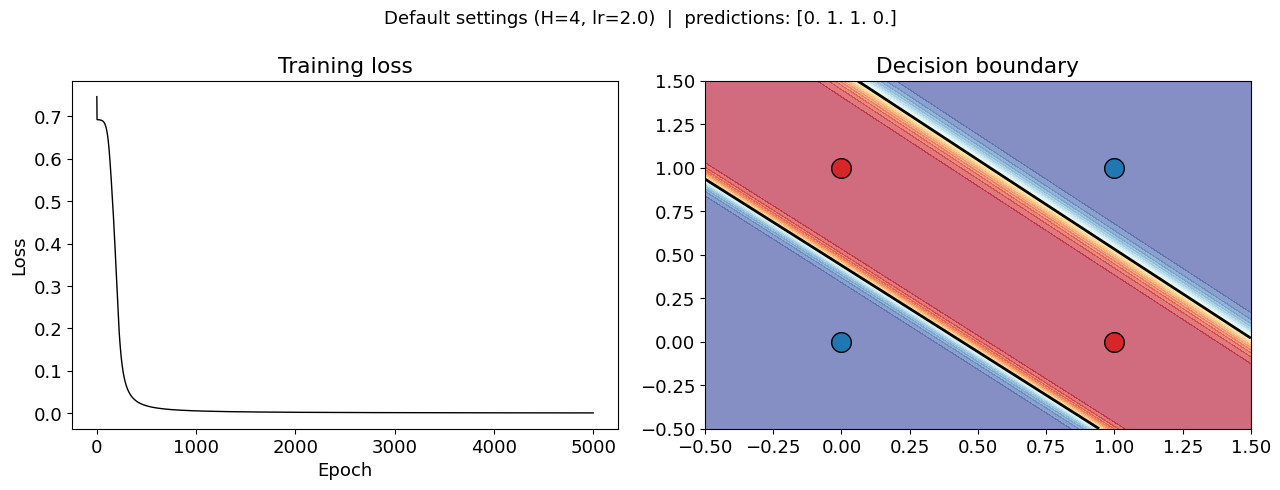

In [7]:
W1, b1, W2, b2, losses = train_network(X_xor, y_xor, H=4, lr=2.0, n_epochs=5000)
plot_xor_result(W1, b1, W2, b2, losses, title='Default settings (H=4, lr=2.0)')

---
## Task 2: Break it — learning rate too high (~3 min)

Set the learning rate to 100. What happens to the loss curve?

Try a few values: `lr = 10, 50, 100`. Can you find the threshold where training breaks?

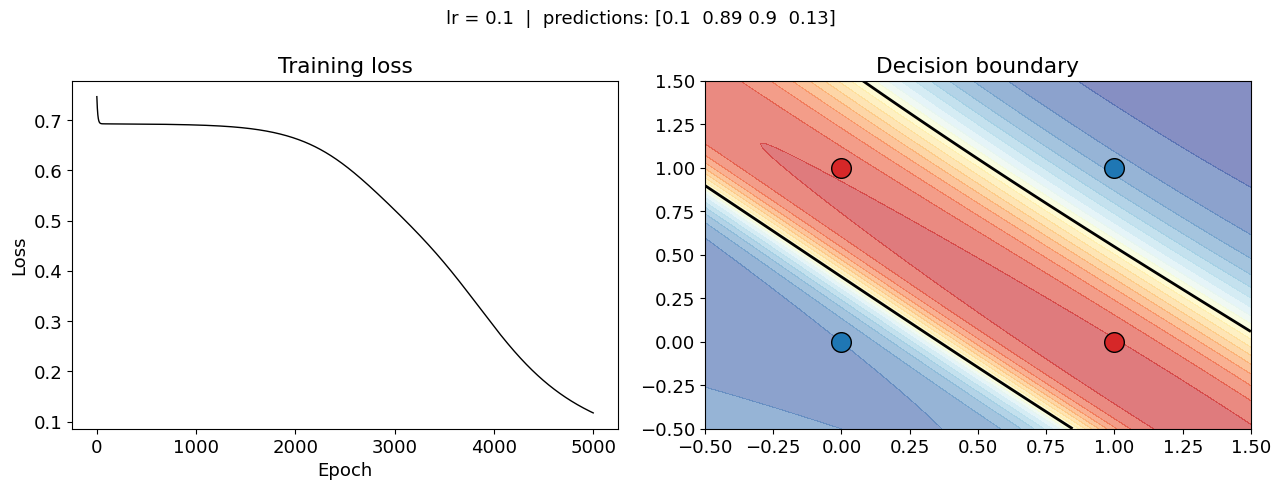

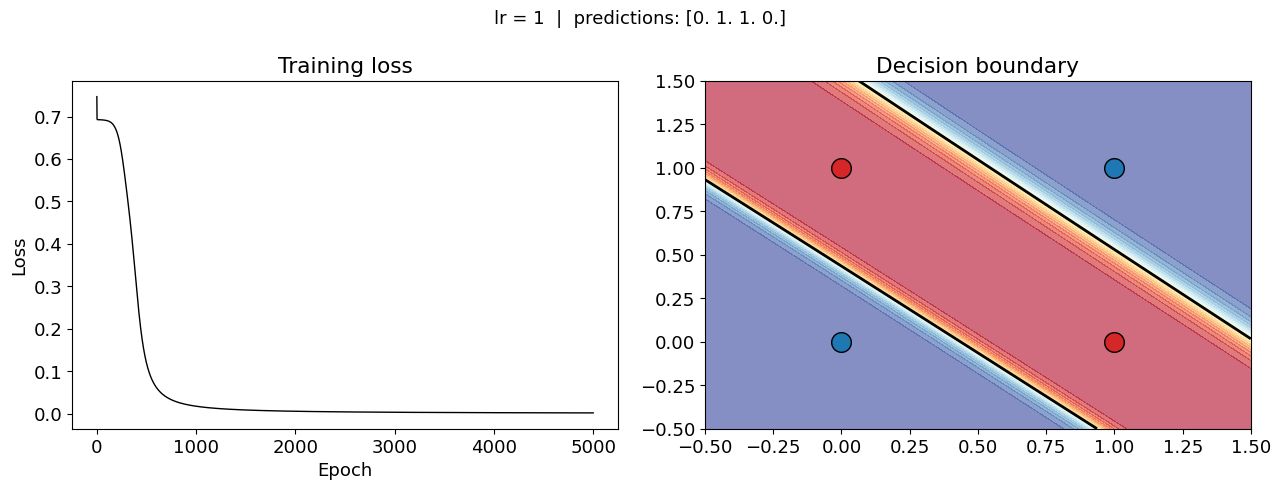

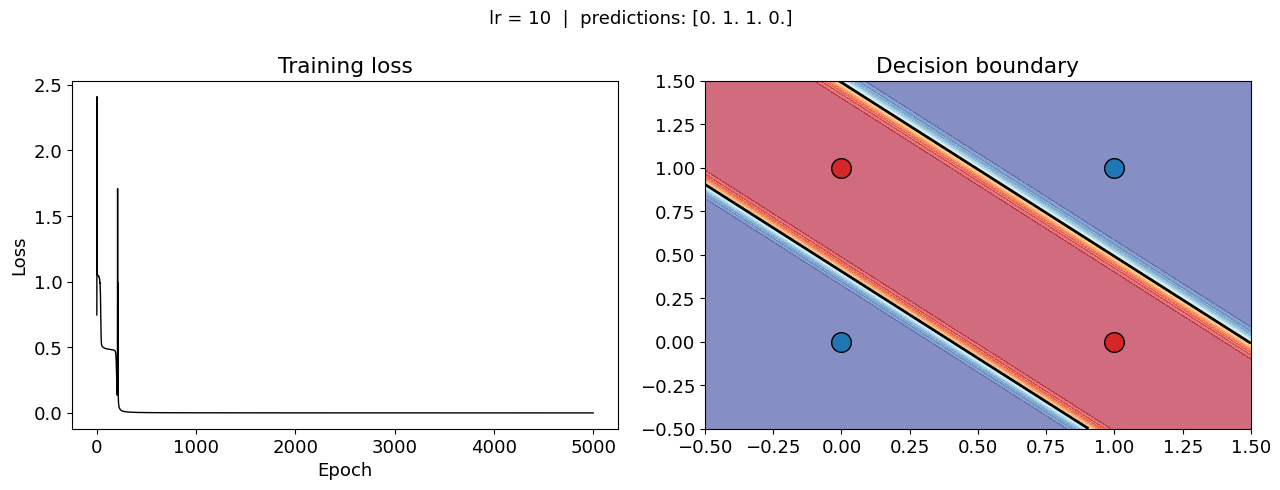

/var/folders/2k/q7xz3f9s0tvb_rts8x0s9g1r0000gn/T/ipykernel_29763/1531255550.py:64: UserWarning: No contour levels were found within the data range.
  axes[1].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)


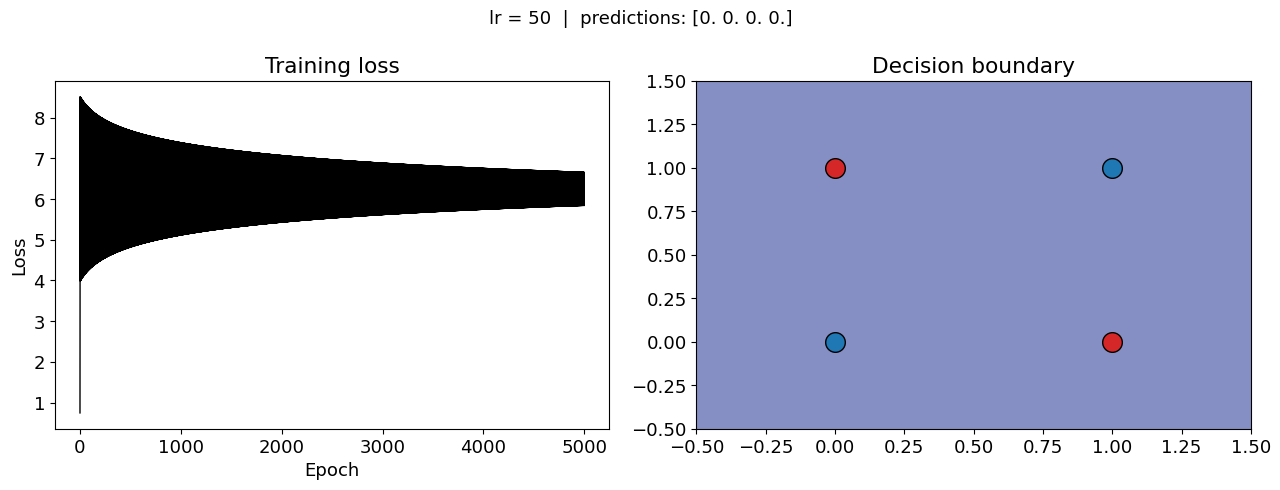

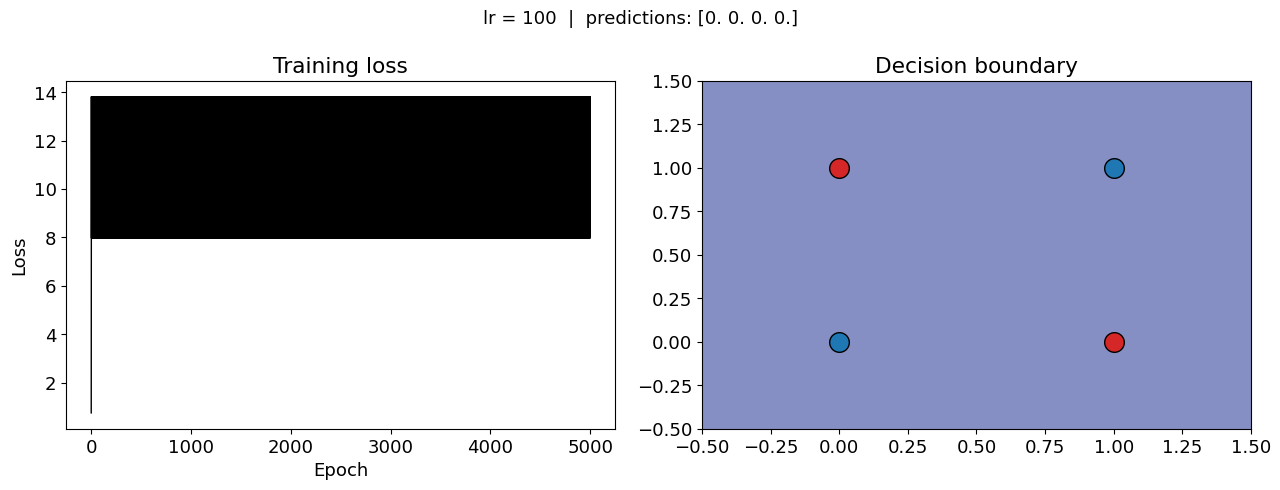

In [16]:
# YOUR CODE HERE — change lr

learnrates = [0.1,1,10,50,100]
for learnrate in learnrates:   
    W1_fast, b1_fast, W2_fast, b2_fast, losses_fast = train_network(X_xor, y_xor, H=4, lr=learnrate, n_epochs=5000)
    plot_xor_result(W1_fast, b1_fast, W2_fast, b2_fast, losses_fast, title=f'lr = {learnrate}')

**What happened?** 

---
## Task 3: Break it — too few neurons (~3 min)

Set `H = 1` (a single hidden neuron). Can the network still solve XOR?

Also try `H = 2`. What is the minimum number of hidden neurons needed?

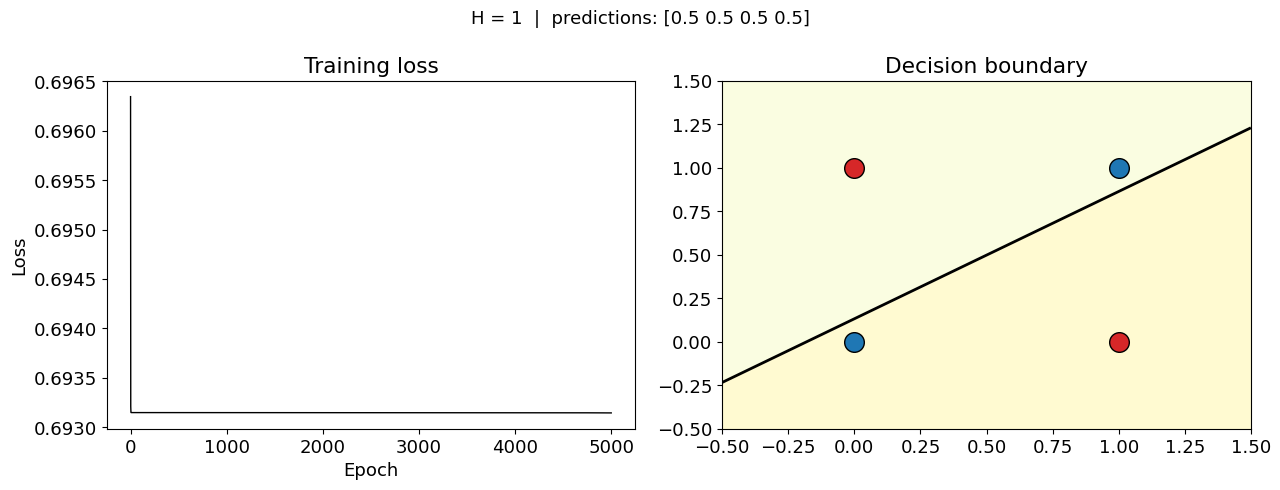

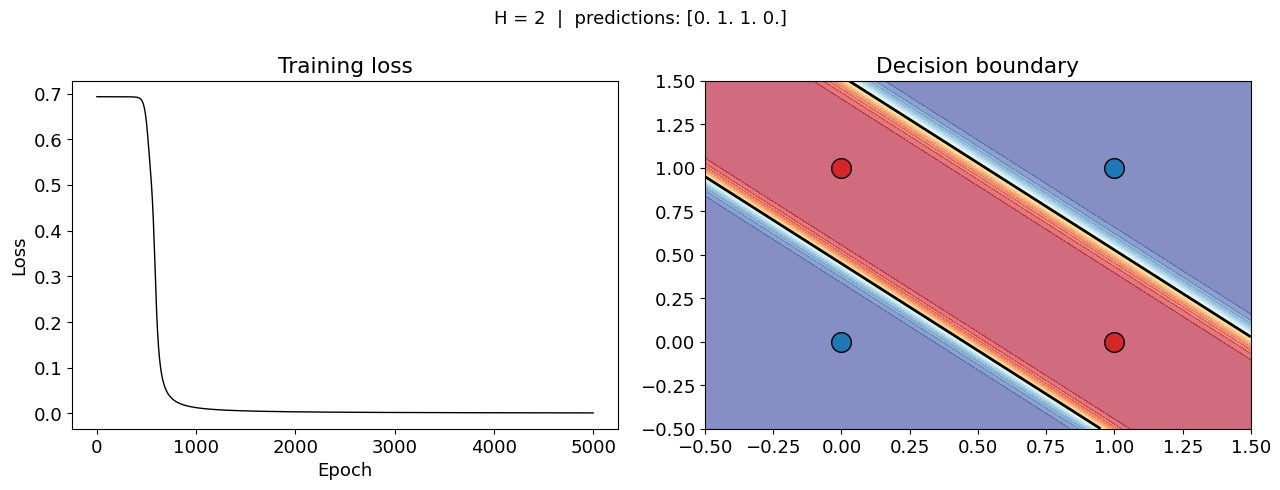

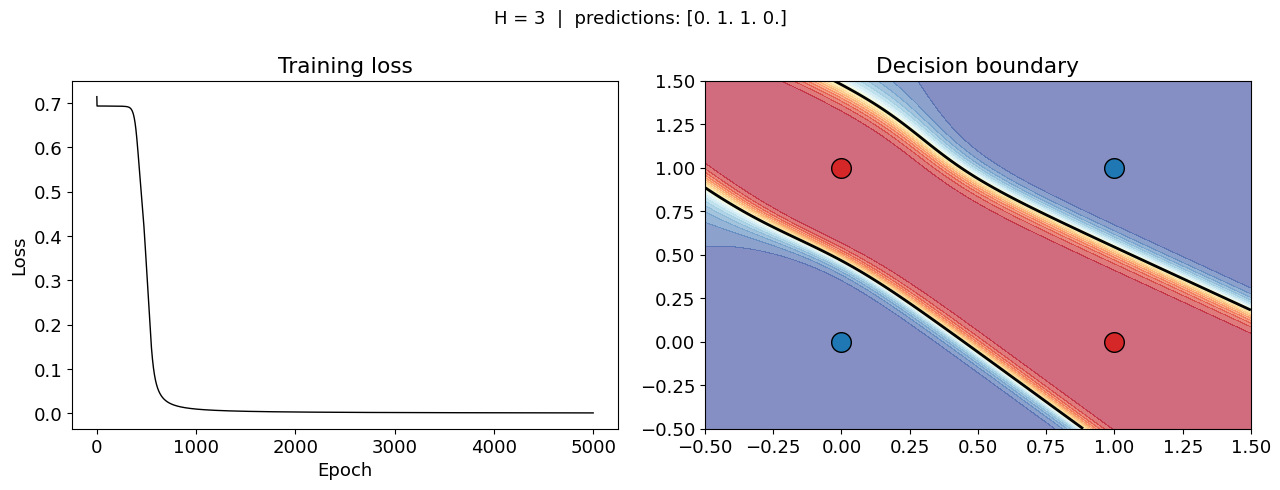

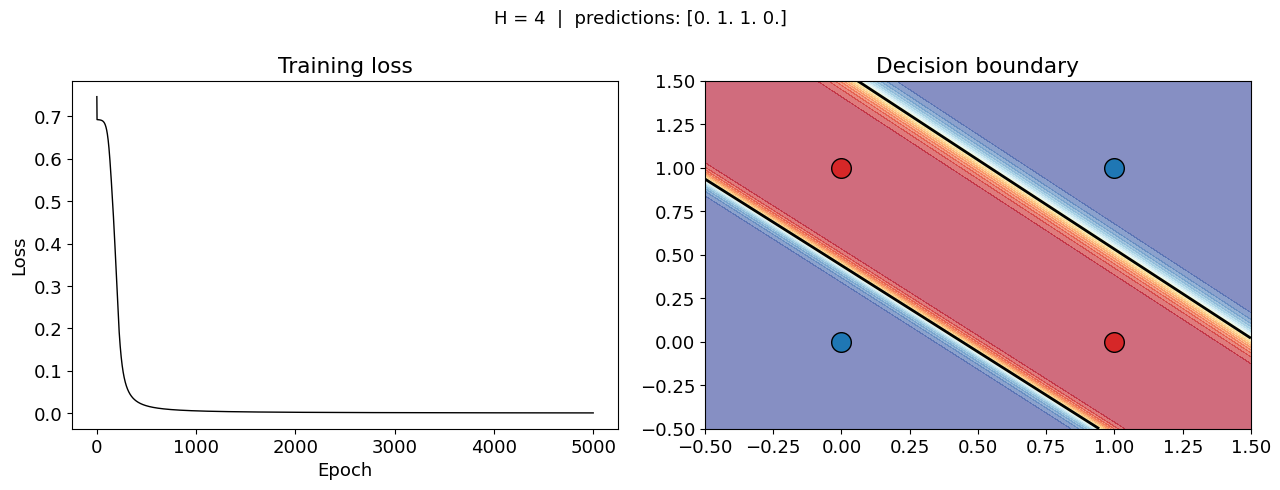

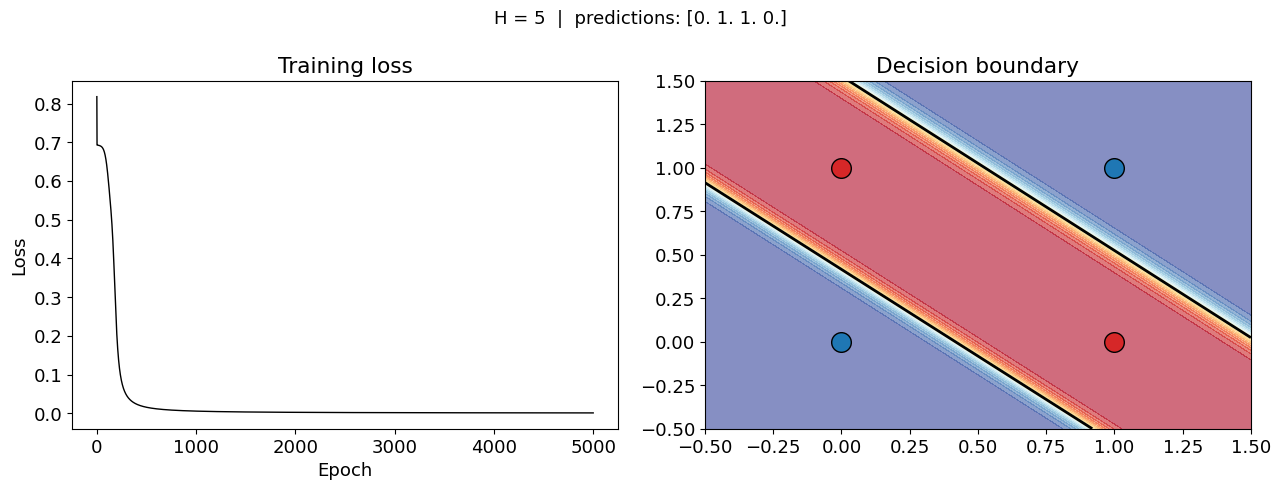

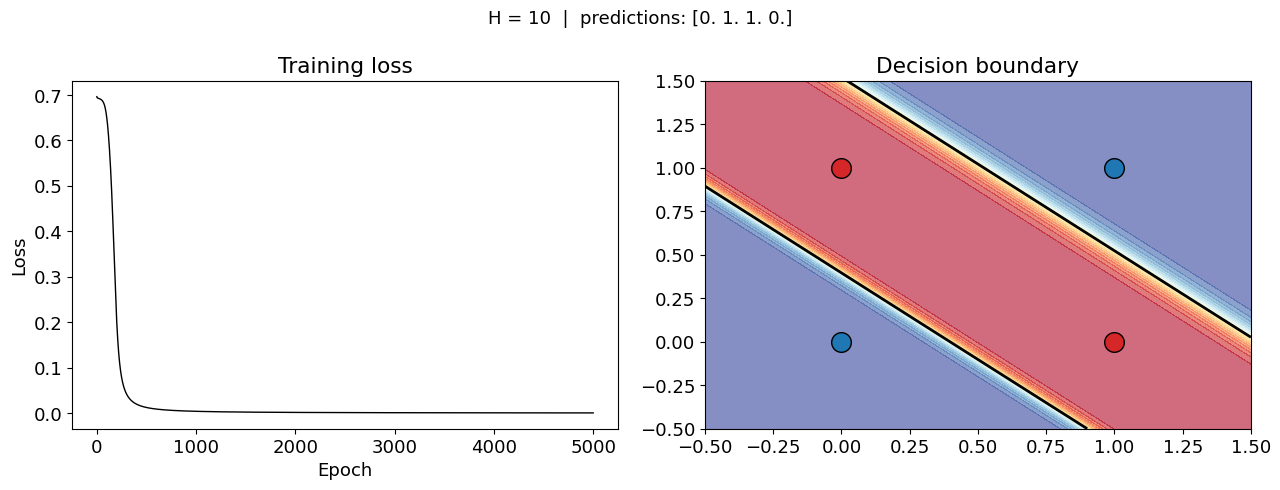

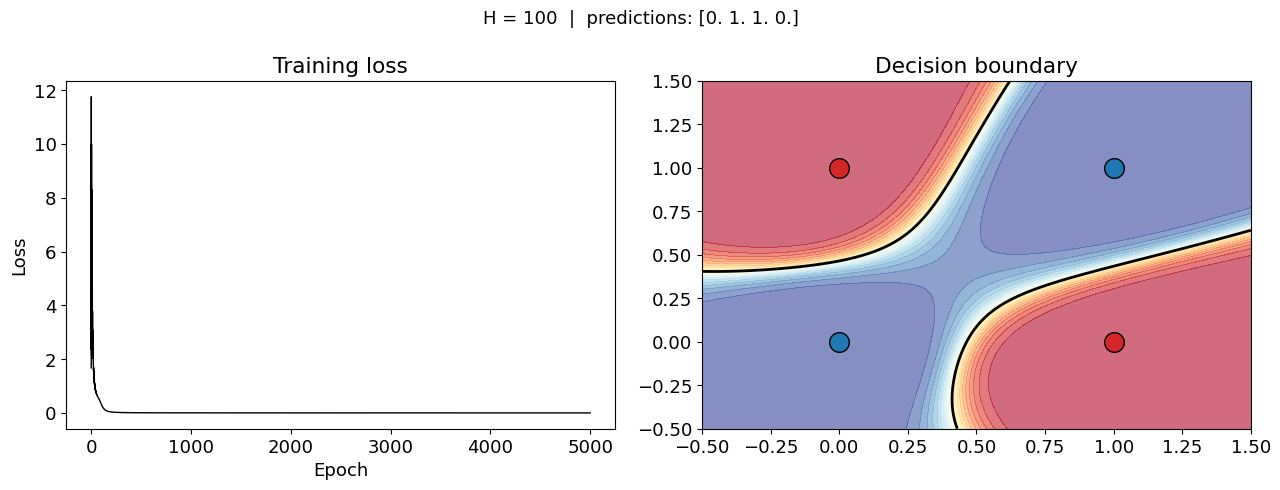

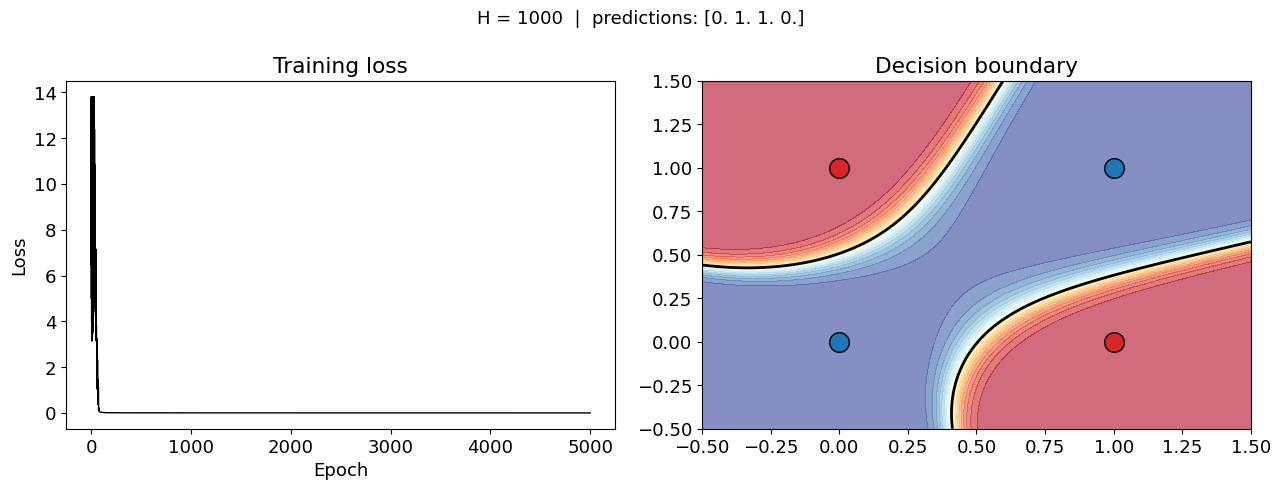

In [25]:
# YOUR CODE HERE — change H
Hs = [1,2,3,4,5,10,100,1000]
for H in Hs:
    W1_small, b1_small, W2_small, b2_small, losses_small = train_network(
        X_xor, y_xor, H=H, lr=2.0, n_epochs=5000
    )
    plot_xor_result(W1_small, b1_small, W2_small, b2_small, losses_small, title=f'H = {H}')

**What happened?** Why can't a single hidden neuron solve XOR?



---
## Task 4: Break it — zero initialization (~3 min)

Set `init_scale = 0` so all weights start at exactly zero. Does the network learn?

Compare to `init_scale = 0.01` (very small but not zero).

/var/folders/2k/q7xz3f9s0tvb_rts8x0s9g1r0000gn/T/ipykernel_29763/1531255550.py:64: UserWarning: No contour levels were found within the data range.
  axes[1].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)


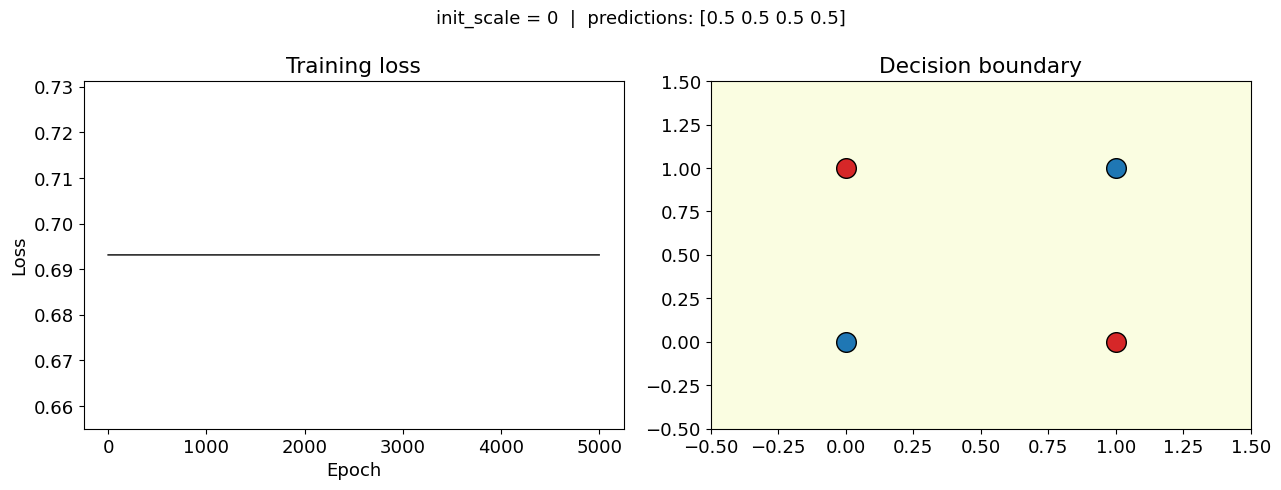

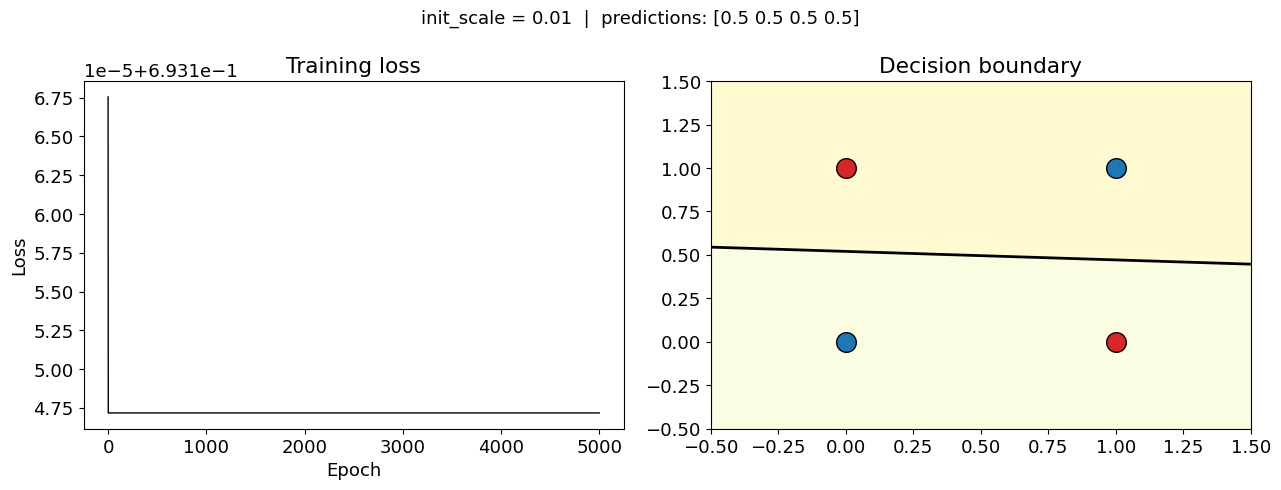

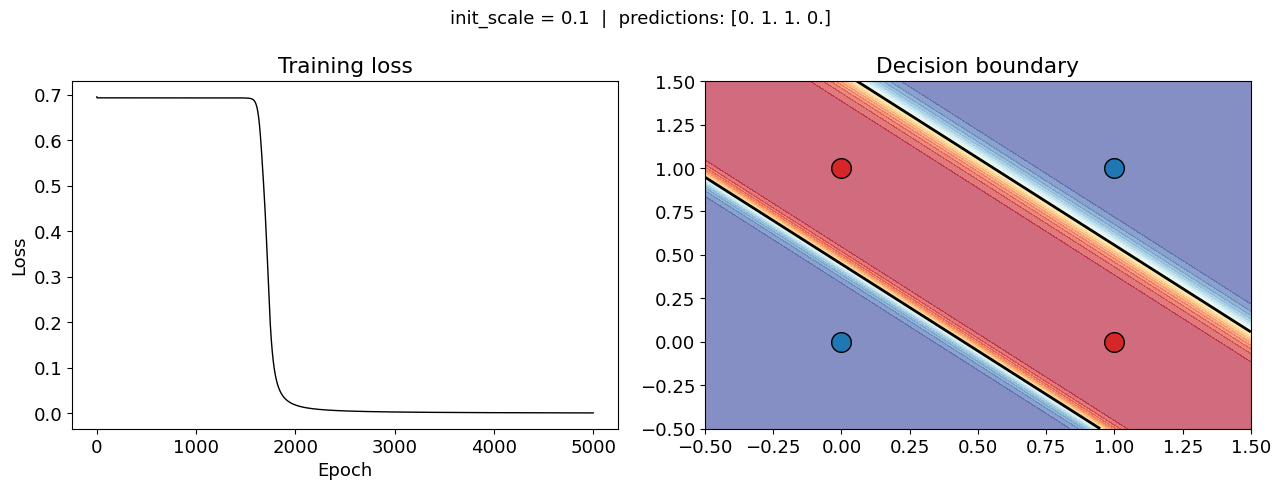

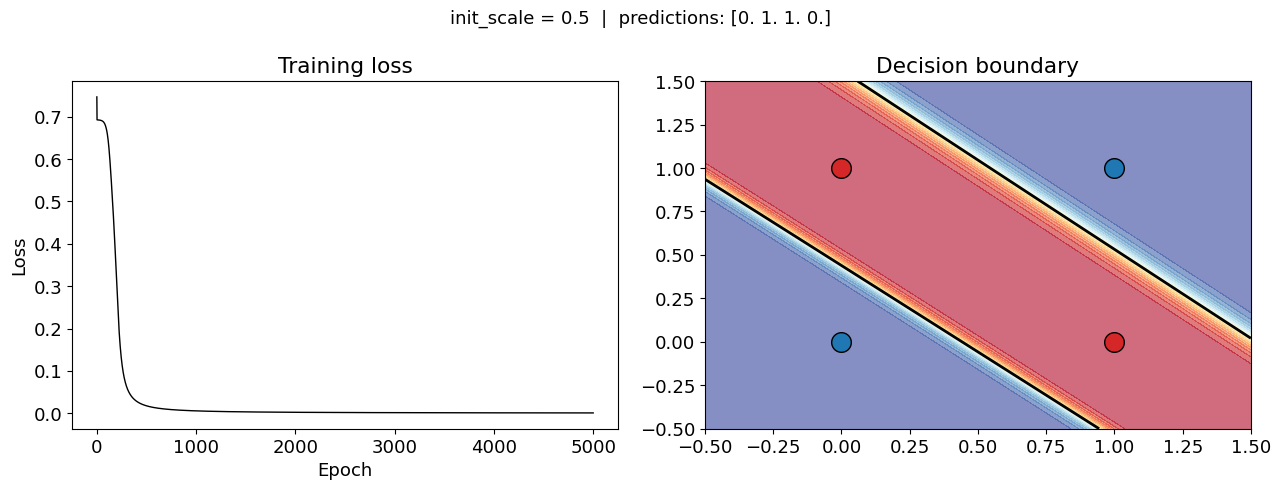

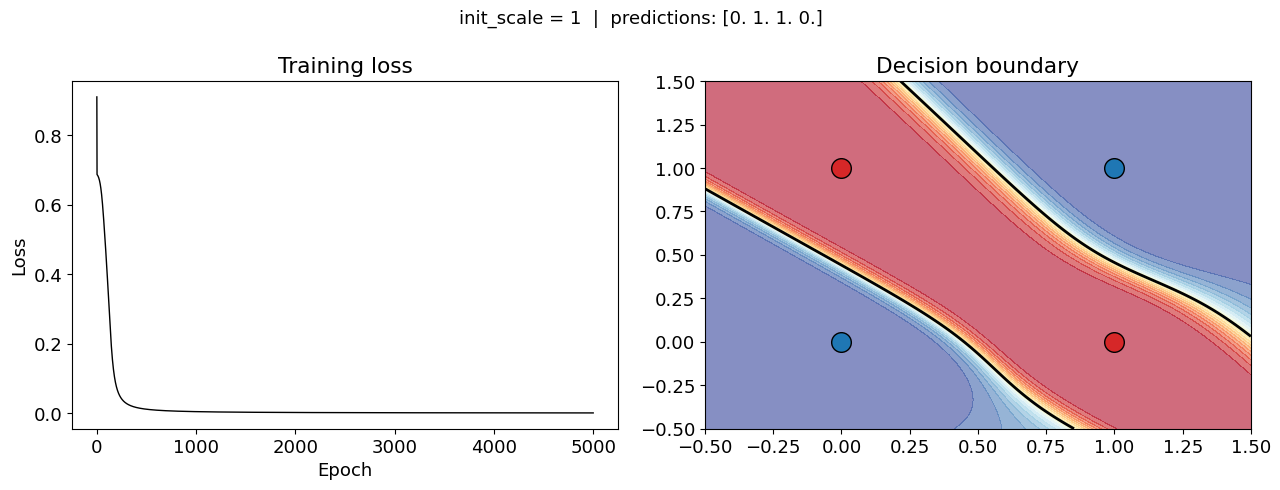

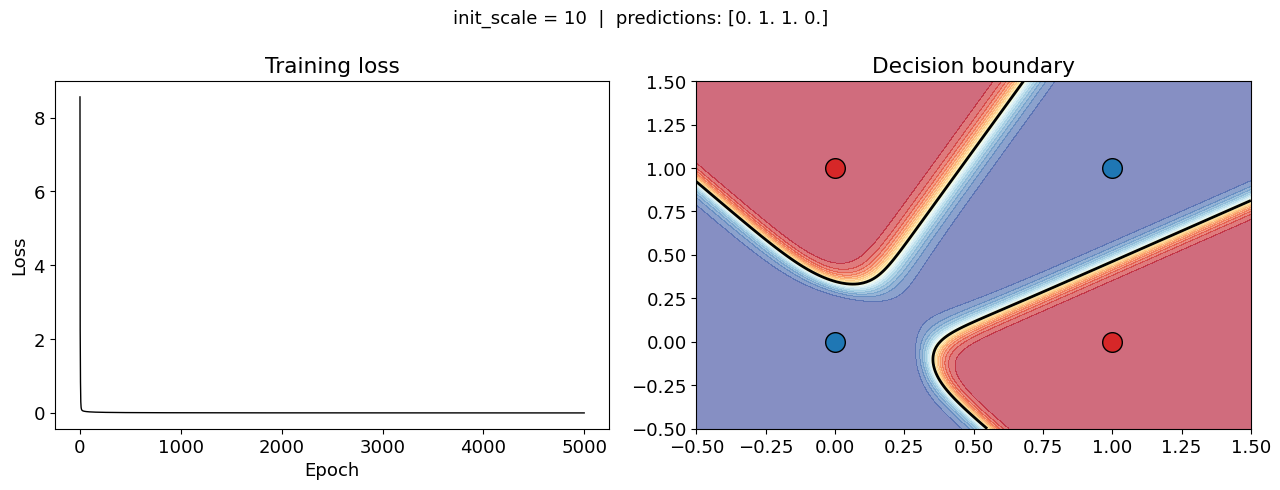

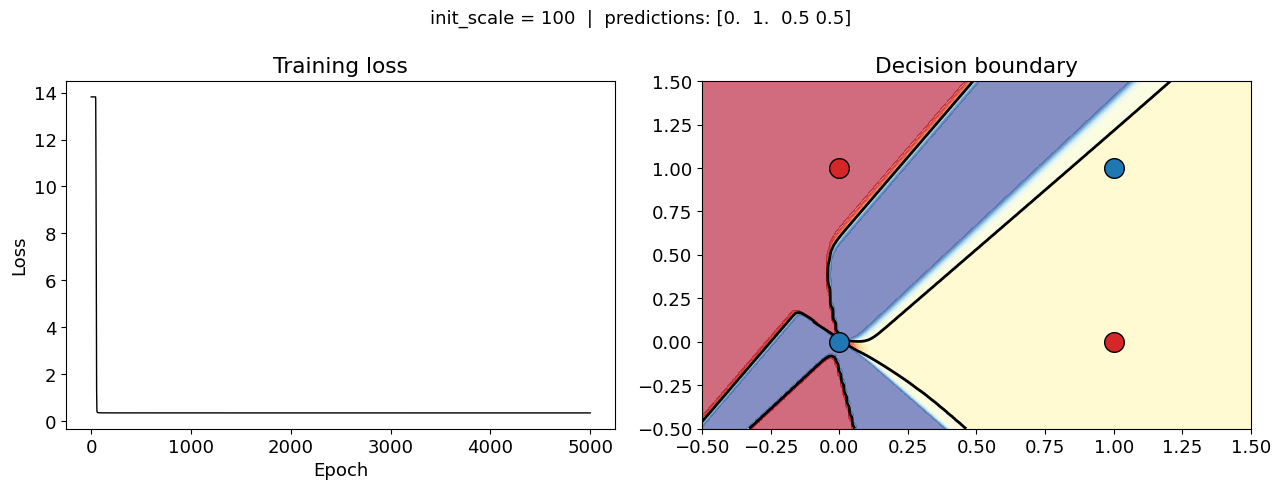

In [30]:
# Zero initialization
scales = [0, 0.01, 0.1, 0.5, 1, 10, 100]
for scale in scales:
    W1_zero, b1_zero, W2_zero, b2_zero, losses_zero = train_network(
        X_xor, y_xor, H=4, lr=2.0, n_epochs=5000, init_scale=scale)
    plot_xor_result(W1_zero, b1_zero, W2_zero, b2_zero, losses_zero, title=f'init_scale = {scale}')

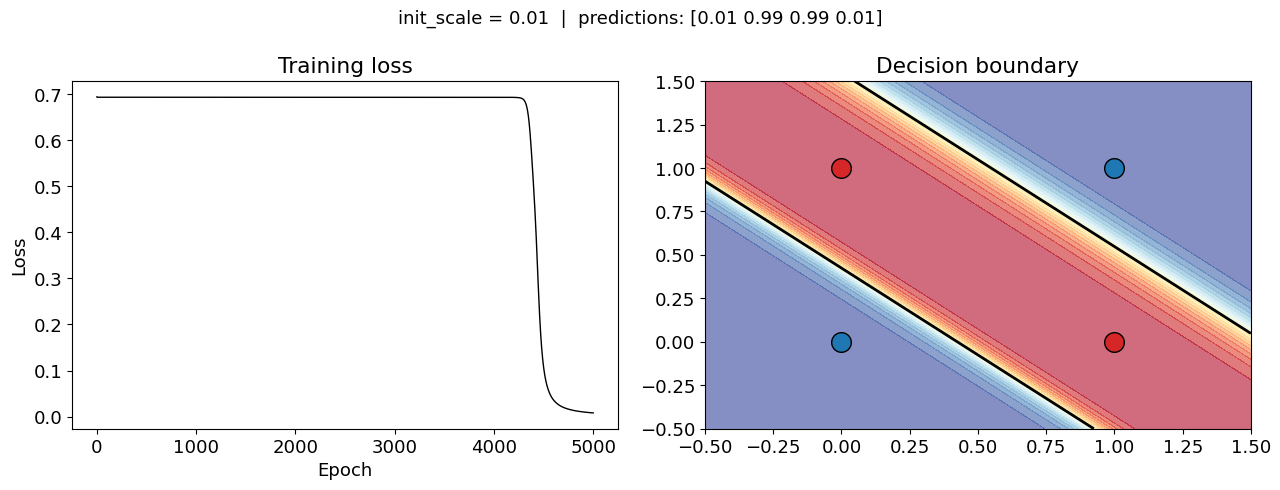

In [29]:
# Very small but nonzero initialization
W1_tiny, b1_tiny, W2_tiny, b2_tiny, losses_tiny = train_network(
    X_xor, y_xor, H=4, lr=2.0, n_epochs=5000, init_scale=0.06
)
plot_xor_result(W1_tiny, b1_tiny, W2_tiny, b2_tiny, losses_tiny, title='init_scale = 0.01')

**What happened?** Why does zero initialization fail even though nonzero works?

(Hint: if all weights are identical, what can you say about the gradients for each hidden neuron?)

*Your answer here*

---
## Bonus: find the best settings

If you finish early: what combination of `H`, `lr`, and `n_epochs` gives you the fastest convergence (lowest loss in the fewest epochs)? Can you get the loss below 0.01 in under 1000 epochs?

In [ ]:
# YOUR BEST ATTEMPT
